<a target="_blank" href="https://colab.research.google.com/github/cesarschoollectures/am-labs/blob/main/assignments/E01_Decision_Tree.ipynb">
<img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# Aprendizado de Máquina

# Questão 1

Utilize o dataset Iris disponível no scikit-learn.
Divida os dados em treino e teste utilizando divisão estratificada.

**Solução**:

In [4]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
import pandas as pd

iris = load_iris()
X = iris.data
y = iris.target


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1, stratify=y
)

print(f"Treino: {X_train.shape[0]} amostras")
print(f"Teste: {X_test.shape[0]} amostras")

Treino: 120 amostras
Teste: 30 amostras


# Questão 2

Treine um modelo utilizando `DecisionTreeClassifier`.

Depois calcule:

- acurácia no treino
- acurácia no teste

**Solução**:

In [10]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

modelo_tree = DecisionTreeClassifier(random_state=1)

modelo_tree.fit(X_train, y_train)

y_pred_treino = modelo_tree.predict(X_train)
y_pred_teste = modelo_tree.predict(X_test)

acuracia_treino = accuracy_score(y_train, y_pred_treino)
acuracia_teste = accuracy_score(y_test, y_pred_teste)


print(f"Acurácia no treino: {acuracia_treino:.2%}")
print(f"Acurácia no teste: {acuracia_teste:.2%}")

Acurácia no treino: 100.00%
Acurácia no teste: 96.67%


# Questão 3

Utilize `plot_tree()` para visualizar a árvore treinada.

Responda:

1. Qual atributo aparece na raiz?
2. Qual é a profundidade da árvore?

**Solução**:

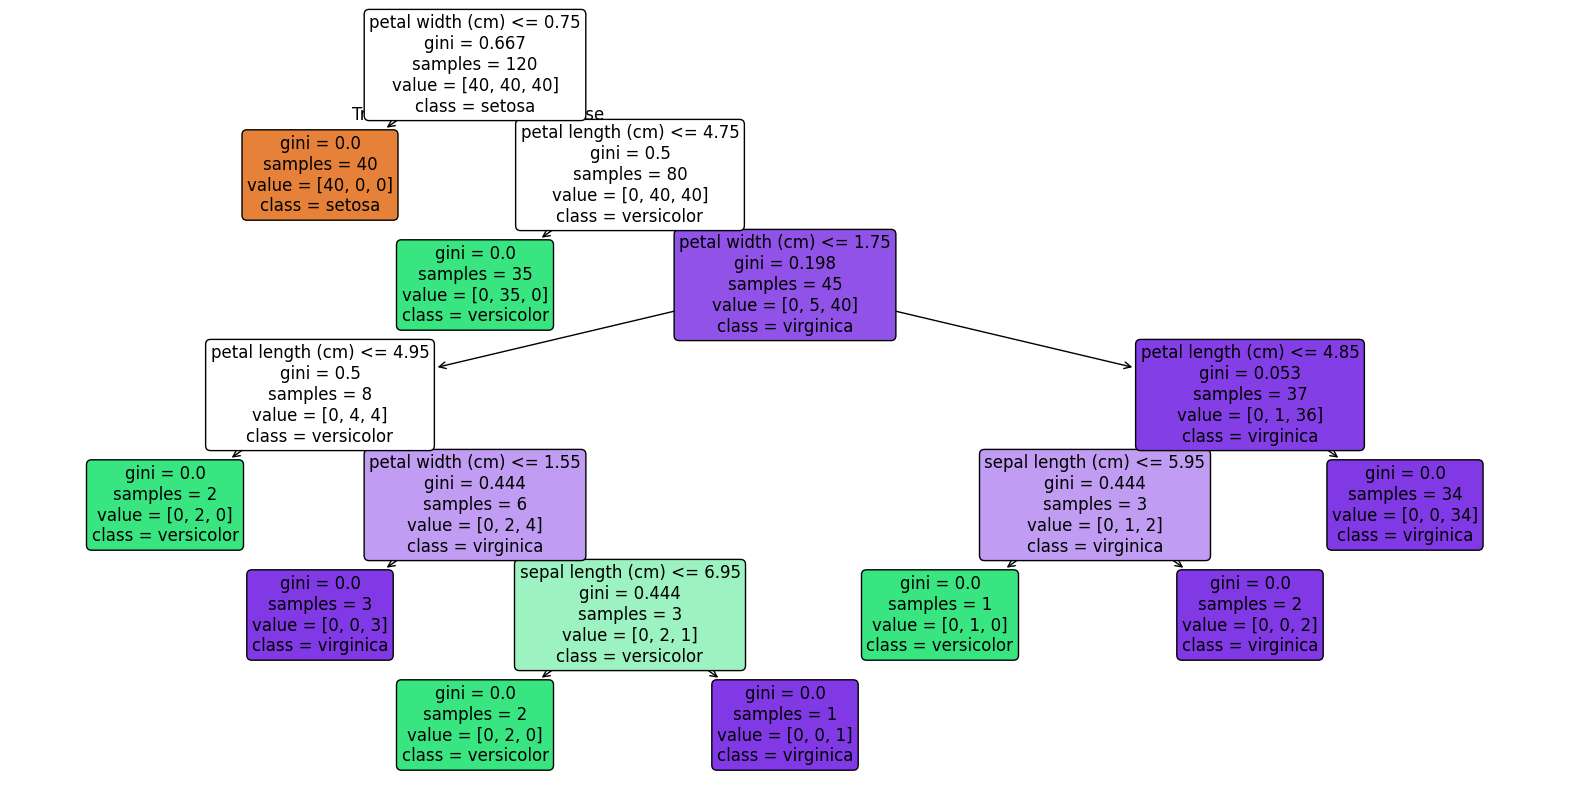

6


In [12]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(20,10))

plot_tree(modelo_tree, 
          feature_names=iris.feature_names, 
          class_names=iris.target_names, 
          filled=True, 
          rounded=True,
          fontsize=12)

plt.show()

print(modelo_tree.get_depth())

**Adicione seu texto de solução aqui**.

# Questão 4

Treine dez árvores com:

- max_depth = 1
- max_depth = 2
- max_depth = 3
...
- max_depth = 9
- max_depth = None

Registre em uma tabela para cada árvore:

- acurácia no treino
- acurácia no teste
- profundidade da árvore
- número de folhas

**Solução**:

In [13]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

profundidades = [1, 2, 3, 4, 5, 6, 7, 8, 9, None]
resultados = []

for depth in profundidades:

    modelo = DecisionTreeClassifier(max_depth=depth, random_state=42)
    modelo.fit(X_train, y_train)
    
    
    acc_treino = accuracy_score(y_train, modelo.predict(X_train))
    acc_teste = accuracy_score(y_test, modelo.predict(X_test))
    profundidade_real = modelo.get_depth()
    num_folhas = modelo.get_n_leaves()
    
    
    resultados.append({
        "Max Depth Config": str(depth),
        "Acurácia Treino": f"{acc_treino:.4f}",
        "Acurácia Teste": f"{acc_teste:.4f}",
        "Profundidade Real": profundidade_real,
        "Número de Folhas": num_folhas
    })


tabela_resultados = pd.DataFrame(resultados)
display(tabela_resultados)

,Max Depth Config,Acurácia Treino,Acurácia Teste,Profundidade Real,Número de Folhas
0,1,0.6667,0.6667,1,2
1,2,0.9583,0.9333,2,3
2,3,0.9583,0.9667,3,4
3,4,0.9750,0.9667,4,6
4,5,0.9917,0.9667,5,8
5,6,1.0000,0.9667,6,9
6,7,1.0000,0.9667,6,9
7,8,1.0000,0.9667,6,9
8,9,1.0000,0.9667,6,9
9,None,1.0000,0.9667,6,9


**Em qual profundidade começa o overfitting?**
**Por que a árvore consegue 100% no treino quando max_depth=None?**

R: A partir do max depth 6

R: Porque usa todos os dados todos os dados do dataser

# Questão 5

Treine dois modelos:

- criterion = "gini"
- criterion = "entropy"

Compare:

- profundidade da árvore
- acurácia

**Solução**:

# Questão 6

Escolha um hiperparâmetro e investigue seu impacto.

Sugestões:

- max_depth
- min_samples_split
- min_samples_leaf
- criterion

Mostre resultados e interprete.
- melhor modelo encontrado
- acurácia
- parâmetros

**Solução**: